# Curating COVID example data


Canadian HV.1 and JN.1 data was downloaded on 2026-02-02 from [ViruSeq Portal](https://virusseq-dataportal.ca/explorer?filters=%7B%22content%22%3A%5B%7B%22content%22%3A%7B%22fieldName%22%3A%22analysis.first_published_at%22%2C%22value%22%3A1696132800000%7D%2C%22op%22%3A%22%3E%3D%22%7D%2C%7B%22content%22%3A%7B%22fieldName%22%3A%22analysis.first_published_at%22%2C%22value%22%3A1704085199999%7D%2C%22op%22%3A%22%3C%3D%22%7D%2C%7B%22content%22%3A%7B%22fieldName%22%3A%22analysis.lineage_analysis.lineage_name%22%2C%22value%22%3A%5B%22HV.1%22%2C%22JN.1%22%2C%22JN.1.1%22%2C%22JN.1.10%22%2C%22JN.1.18%22%2C%22JN.1.19%22%2C%22JN.1.2%22%2C%22JN.1.22%22%2C%22JN.1.31%22%2C%22JN.1.39%22%2C%22JN.1.4%22%2C%22JN.1.4.5%22%2C%22JN.1.4.7%22%2C%22JN.1.41%22%2C%22JN.1.44%22%2C%22JN.1.45%22%2C%22JN.1.47.1%22%2C%22JN.1.5%22%2C%22JN.1.52%22%2C%22JN.1.55%22%2C%22JN.1.6%22%2C%22JN.1.60%22%2C%22JN.1.8%22%2C%22JN.1.8.3%22%2C%22JN.1.9%22%5D%7D%2C%22op%22%3A%22in%22%7D%5D%2C%22op%22%3A%22and%22%7D) by selecting all data submitted between 2023-10-01 and 2023-12-31 with lineage name equal to 'HV.1', 'JN.1' or starting with 'JN.1.'.



Import necessary packages


In [1]:
import pandas as pd
import Bio.SeqIO
from tqdm import tqdm
import yaml

## Double checking data contains only HV.1 and JN.1 sequences
### Metadata

In [2]:
metadata = pd.read_csv('virusseq-search-export-2026-02-02/metadata.tsv',
    parse_dates=[ 'submission date', 'sample collection date'], sep='\t')
with open('sub_variants_map.yaml', 'r') as file:
    sub_variants_map = yaml.safe_load(file)
allowed_lineages = [item for sublist in sub_variants_map.values() for item in sublist]
metadata = metadata[metadata['lineage name'].isin(allowed_lineages)]

### Sequences


In [3]:
HV_1_and_JN1_sequences = []
for record in tqdm(Bio.SeqIO.parse('virusseq-search-export-2026-02-02/sequences.fasta',
    'fasta')):
    if record.id in metadata['fasta header name'].values:
        HV_1_and_JN1_sequences.append(record)
with open('HV_1_and_JN_1_sequences_unaligned.fasta', 'w') as file:
    Bio.SeqIO.write(HV_1_and_JN1_sequences, file, 'fasta')
file.close()

6721it [00:07, 898.41it/s] 


## Explore metadata

Counts of lineages

In [4]:
metadata['lineage name'].value_counts()

lineage name
HV.1         6300
JN.1          179
JN.1.1         80
JN.1.4         49
JN.1.2         47
JN.1.22        21
JN.1.31        10
JN.1.4.5        9
JN.1.9          5
JN.1.47.1       3
JN.1.5          2
JN.1.6          2
JN.1.19         2
JN.1.8.3        1
JN.1.45         1
JN.1.41         1
JN.1.44         1
JN.1.60         1
JN.1.10         1
JN.1.8          1
JN.1.52         1
JN.1.4.7        1
JN.1.55         1
JN.1.39         1
JN.1.18         1
Name: count, dtype: int64

How many JN.1 & all its sublineages

In [5]:
len(metadata[metadata['lineage name']!='HV.1'])

421

Collection date data for all HV.1.

In [6]:
metadata[metadata['lineage name']=='HV.1']['sample collection date'].describe()

count                             6300
mean     2023-10-28 06:09:08.571428352
min                2023-08-15 00:00:00
25%                2023-10-14 00:00:00
50%                2023-11-01 00:00:00
75%                2023-11-14 00:00:00
max                2023-12-08 00:00:00
Name: sample collection date, dtype: object

Collection date data for all JN.1 and its sublineages.

In [7]:
metadata[metadata['lineage name']!='HV.1']['sample collection date'].describe()

count                              421
mean     2023-11-18 14:35:37.767220736
min                2023-10-09 00:00:00
25%                2023-11-15 00:00:00
50%                2023-11-21 00:00:00
75%                2023-11-25 00:00:00
max                2023-12-04 00:00:00
Name: sample collection date, dtype: object

## Aligning and masking Sequences

Sequences will be aligned using Nextclade.

### Obtaining Reference genome

In [8]:
%%bash
source activate beast_pype_data_curation
nextclade dataset get --name 'nextstrain/sars-cov-2/wuhan-hu-1/orfs' --output-dir 'nextclade-sars-cov-2'

### Align Sequences

In [9]:
%%bash
source activate beast_pype_data_curation
nextclade run \
   --input-dataset nextclade-sars-cov-2 \
   --output-all=output/ \
   HV_1_and_JN_1_sequences_unaligned.fasta

### Post-Alignment checks

#### All from the JN.1 or HV.1.

In [10]:
nextclade_df = pd.read_csv('output/nextclade.tsv', sep='\t')
nextclade_df.Nextclade_pango.value_counts()


Nextclade_pango
HV.1         6296
JN.1          180
JN.1.1         79
JN.1.4         47
JN.1.2         47
JN.1.22        21
JN.1.4.5       11
JN.1.31        10
JN.1.9          5
HV.1.6          4
JN.1.47.1       3
JN.1.6          2
JN.1.19         2
JN.1.5          2
JN.1.8.3        1
JN.1.32         1
JN.1.41         1
JN.1.44         1
JN.1.60         1
JN.1.10         1
JN.1.8          1
JN.1.52         1
JN.1.4.7        1
JN.1.55.1       1
JN.1.39         1
JN.1.18         1
Name: count, dtype: int64

That is fine. 

#### Check coverage

In [11]:
nextclade_df.coverage.describe()

count    6721.000000
mean        0.987797
std         0.012645
min         0.900880
25%         0.987493
50%         0.992409
75%         0.994181
max         0.995920
Name: coverage, dtype: float64

<Axes: ylabel='Frequency'>

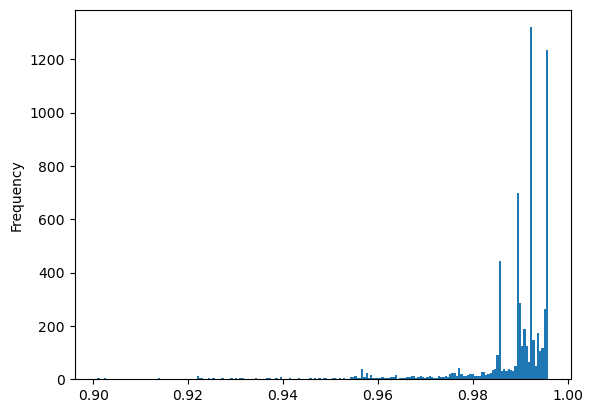

In [12]:
nextclade_df.coverage.plot.hist(bins=200)

## Increasing coverage to >= 0.98 and Saving Selection of HV.1 & JN.1 Sequences

In [13]:
sequences_ids_better_coverage = nextclade_df[nextclade_df.coverage>=0.98]['seqName'].values
metadata = metadata[metadata['fasta header name'].isin(sequences_ids_better_coverage)]
metadata.to_csv('HV_1_and_JN_1_metadata.csv', index=False)

In [14]:
selected_HV_1_and_JN1_sequences = []
for record in tqdm(Bio.SeqIO.parse('output/nextclade.aligned.fasta',
    'fasta')):
    if record.id in sequences_ids_better_coverage:
        selected_HV_1_and_JN1_sequences.append(record)
with open('HV_1_and_JN_1_sequences.fasta', 'w') as file:
    Bio.SeqIO.write(selected_HV_1_and_JN1_sequences, file, 'fasta')
file.close()

6721it [00:05, 1227.03it/s]


## Putting JN.1 Sequences in there own dataset

In [15]:
JN1_metadata = metadata[metadata['lineage name']!='HV.1']
JN1_metadata.to_csv('JN_1_metadata.csv', index=False)


In [16]:
JN1_ids = JN1_metadata['fasta header name'].values
JN1_sequences = []

for record in tqdm(Bio.SeqIO.parse('HV_1_and_JN_1_sequences.fasta', 'fasta')):
    if record.id in JN1_ids:
        JN1_sequences.append(record)
with open('JN_1_sequences.fasta', 'w') as file:
    Bio.SeqIO.write(JN1_sequences, file, 'fasta')
file.close()

5920it [00:00, 9013.22it/s]


### Trying to get under GitHubs file size limit (idealy 50 MiB, hard limit 100 Mib)

In [19]:
JN1_metadata.describe()

,submission date,sample collection date,sample collection date null reason,diagnostic pcr Ct value
count,397,397,0.0,189.000000
mean,2023-12-10 21:38:32.342569216,2023-11-18 12:48:58.035264256,NaN,18.898254
min,2023-11-01 00:00:00,2023-10-09 00:00:00,NaN,10.930000
25%,2023-12-12 00:00:00,2023-11-15 00:00:00,NaN,16.090000
50%,2023-12-14 00:00:00,2023-11-21 00:00:00,NaN,18.400000
75%,2023-12-14 00:00:00,2023-11-25 00:00:00,NaN,21.220000
max,2023-12-21 00:00:00,2023-12-04 00:00:00,NaN,28.680000
std,NaN,NaN,NaN,3.715145


In [21]:
metadata[metadata['lineage name']=='HV.1'].describe()

,submission date,sample collection date,sample collection date null reason,diagnostic pcr Ct value
count,5523,5523,0.0,2741.000000
mean,2023-11-27 08:01:49.505703424,2023-10-27 19:28:34.937533952,NaN,20.048158
min,2023-10-03 00:00:00,2023-08-15 00:00:00,NaN,9.780000
25%,2023-11-15 00:00:00,2023-10-12 00:00:00,NaN,17.200000
50%,2023-11-30 00:00:00,2023-10-31 00:00:00,NaN,19.500000
75%,2023-12-14 00:00:00,2023-11-13 00:00:00,NaN,22.600000
max,2023-12-27 00:00:00,2023-12-08 00:00:00,NaN,32.290000
std,NaN,NaN,NaN,3.754111
